In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

In [ ]:

df = pd.read_csv('Country-data.csv')
display(df.head())

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
display(df.info())
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 14.5 KB


None

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


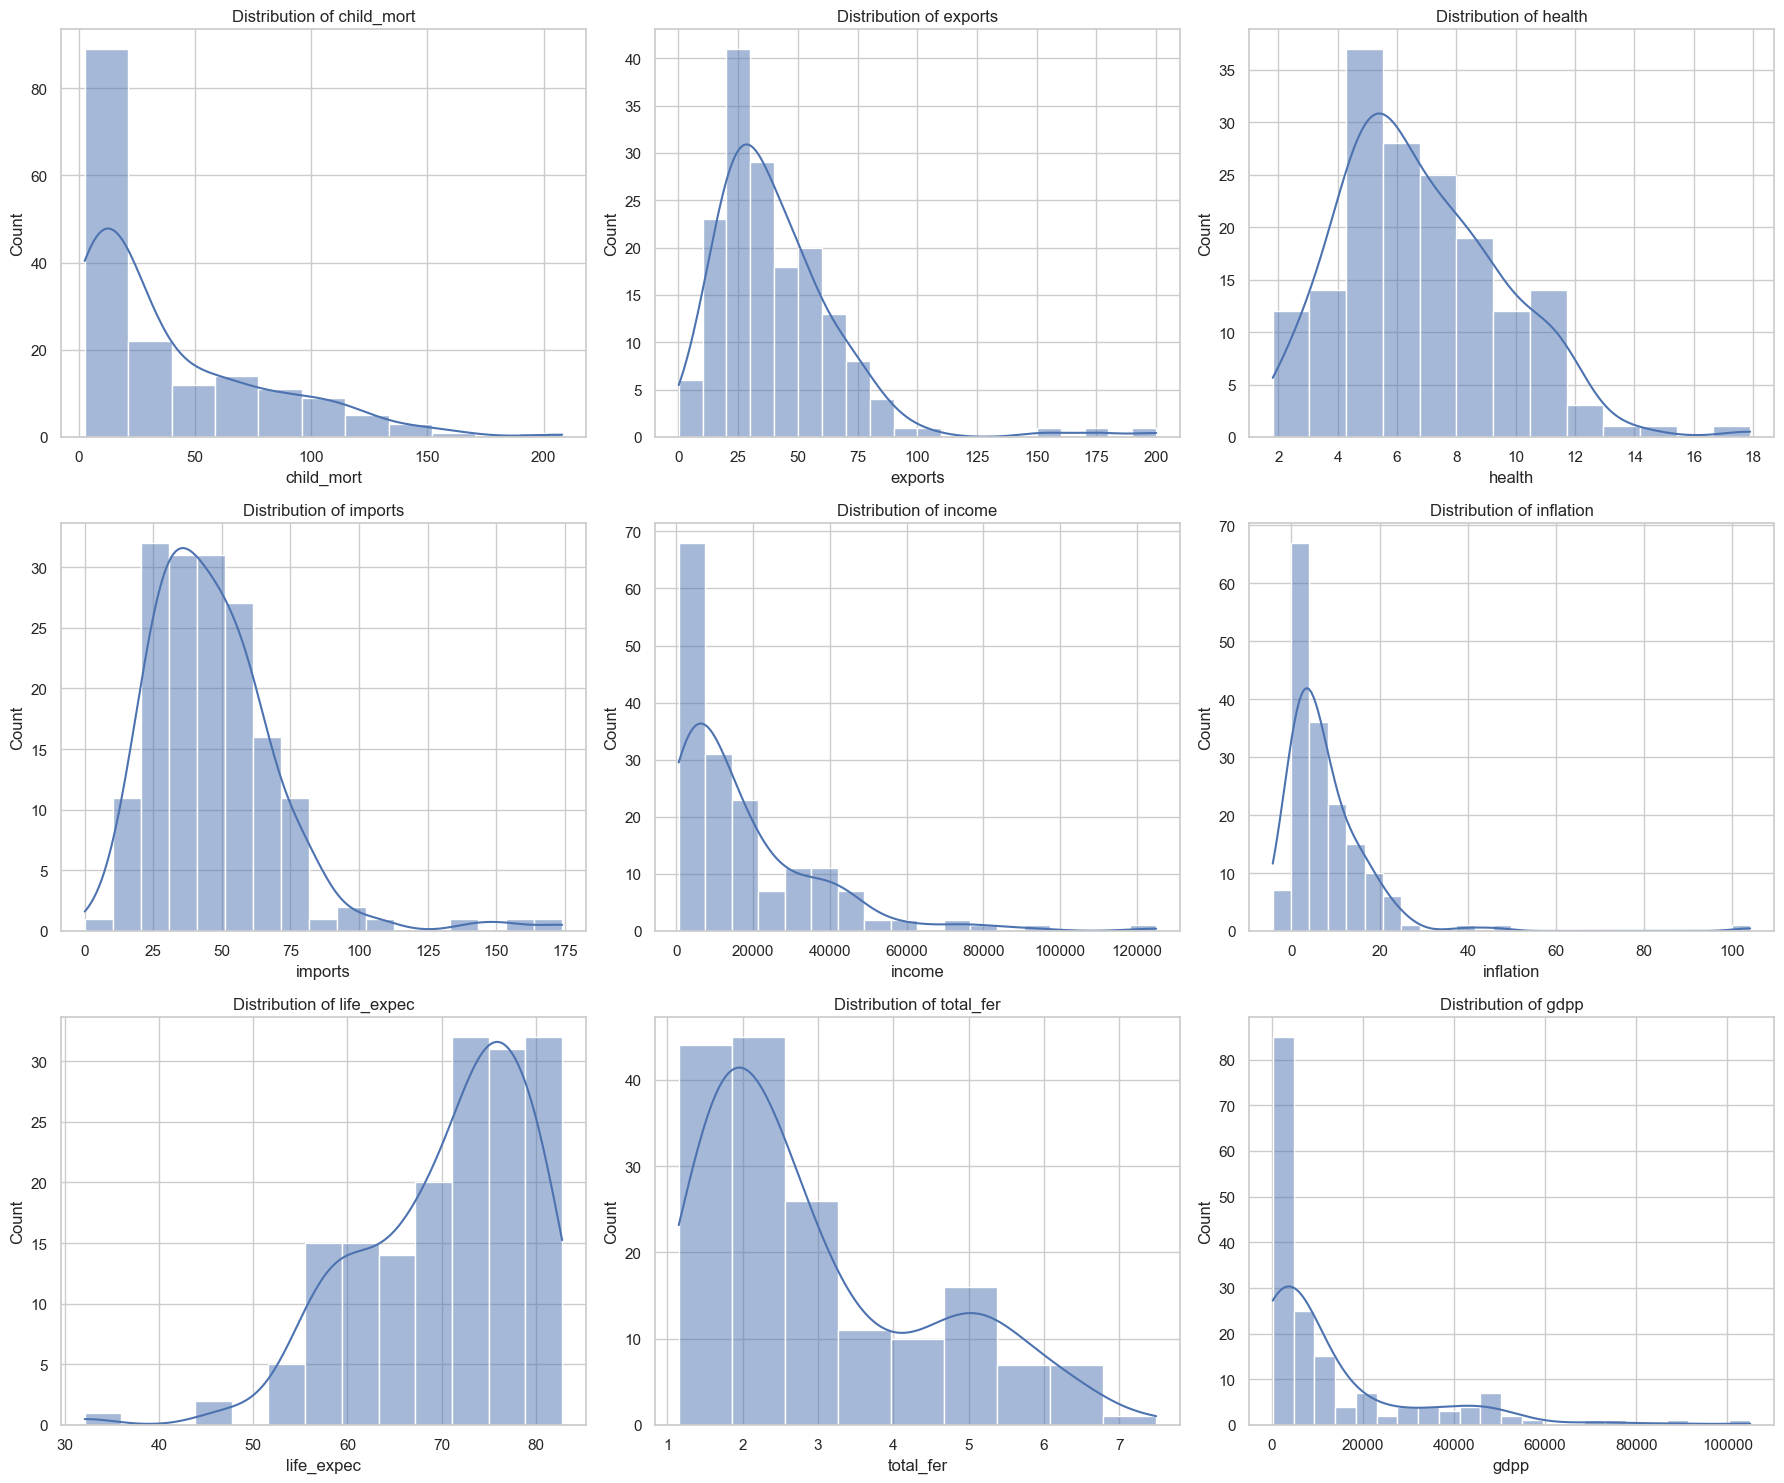

In [ ]:

features = df.columns[1:] # Exclude 'country'
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

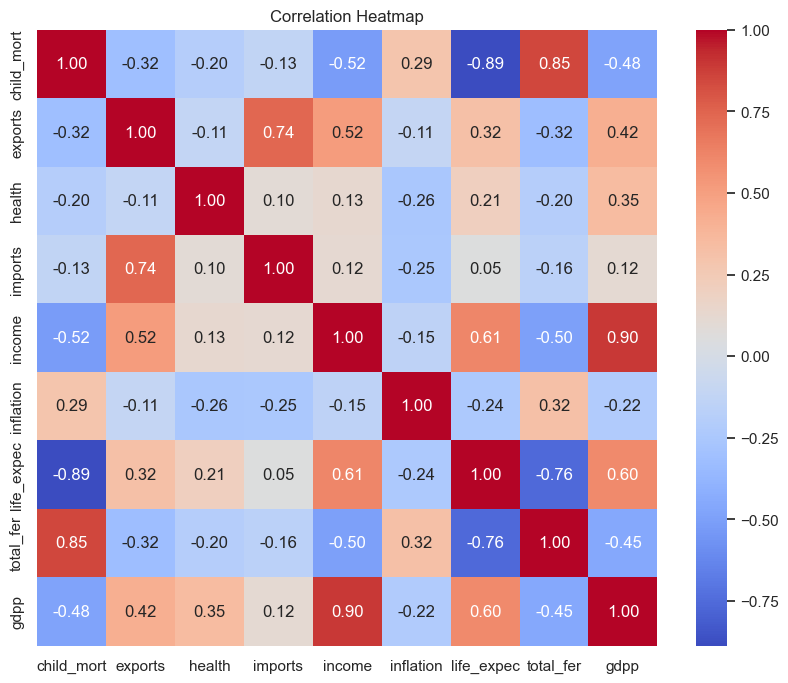

In [ ]:

plt.figure(figsize=(10, 8))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
X = df.drop('country', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

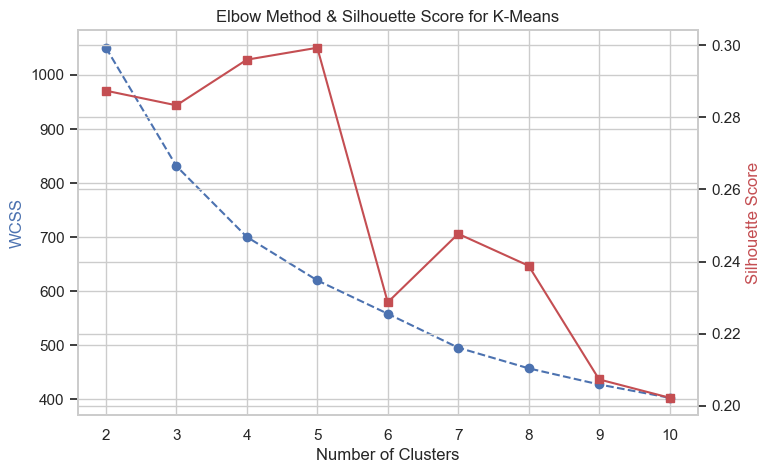

In [ ]:

wcss = []
sil_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(range(2, 11), wcss, marker='o', linestyle='--', color='b', label='WCSS')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('WCSS', color='b')
ax2 = ax1.twinx()
ax2.plot(range(2, 11), sil_scores, marker='s', linestyle='-', color='r', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
plt.title('Elbow Method & Silhouette Score for K-Means')
plt.show()

Final K-Means Silhouette Score: 0.283


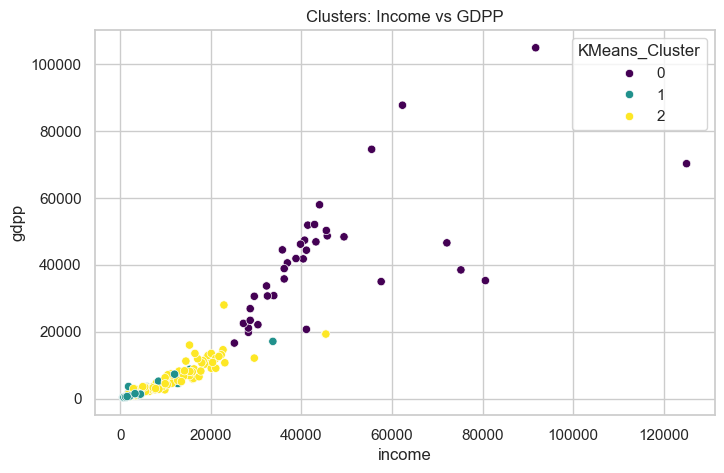

In [ ]:

kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)
print(f"Final K-Means Silhouette Score: {silhouette_score(X_scaled, df['KMeans_Cluster']):.3f}")

# Visualize Clusters (Income vs GDPP)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='income', y='gdpp', hue='KMeans_Cluster', data=df, palette='viridis')
plt.title('Clusters: Income vs GDPP')
plt.show()

In [ ]:

dbscan = DBSCAN(eps=2.0, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)
print("DBSCAN Cluster value counts:")
print(df['DBSCAN_Cluster'].value_counts())

DBSCAN Cluster value counts:
DBSCAN_Cluster
 0    152
-1     15
Name: count, dtype: int64


In [ ]:
y = df['KMeans_Cluster']
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training instances: {X_train.shape[0]}, Test instances: {X_test.shape[0]}")

Training instances: 133, Test instances: 34


In [ ]:

rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7], 
    'min_samples_split': [2, 5]
}


rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f"Best RF Parameters: {rf_grid.best_params_}")
best_rf = rf_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Best RF Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [ ]:

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [2, 3, 5], # Shallow trees for small dataset to prevent overfitting
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0] # Subsampling helps generalization
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print(f"Best XGBoost Parameters: {xgb_grid.best_params_}")
best_xgb = xgb_grid.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



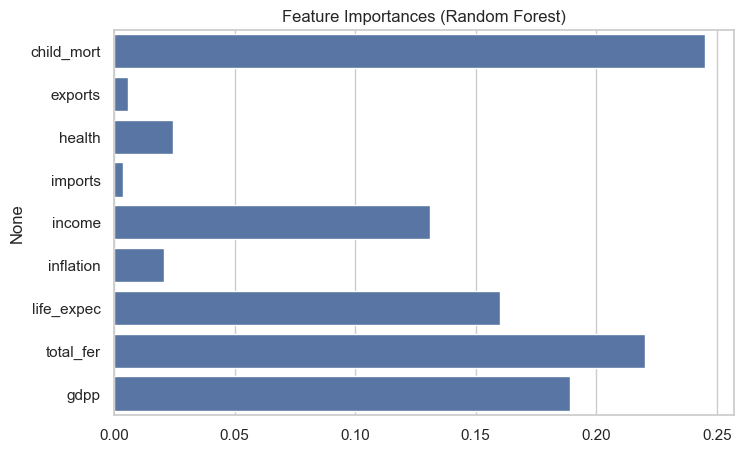

In [ ]:

plt.figure(figsize=(8, 5))
sns.barplot(x=best_rf.feature_importances_, y=X.columns)
plt.title('Feature Importances (Random Forest)')
plt.show()